In [48]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler,LabelEncoder 

from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier 
import xgboost
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

# Load Dataset

In [49]:
# loading the dataset 
DATA_PATH = "D:\laptop\College\GP\Fertilizer_Recommendation\data\Fertilizer_Augmented_Data.csv"
df=pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df.head()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Soil Type,Crop Type,Fertilizer Name
0,34,52,43,24,0,22,Black,Paddy,28-28
1,31,66,33,22,0,25,Clayey,Tobacco,28-28
2,30,59,37,40,0,0,Red,Sugarcane,Urea
3,36,49,33,15,13,13,Red,Cotton,17-17-17
4,35,64,15,8,8,31,Black,Maize,14-35-14


# Data Preprocessing

In [50]:
# checking the shape of dataset 
df.shape 

(2100, 9)

In [51]:
# checking the column of dataset 
df.columns

Index(['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium',
       'Phosphorous', 'Soil Type', 'Crop Type', 'Fertilizer Name'],
      dtype='object')

In [52]:
# checking the null values in dataset 
df.isnull().sum()

Temparature        0
Humidity           0
Moisture           0
Nitrogen           0
Potassium          0
Phosphorous        0
Soil Type          0
Crop Type          0
Fertilizer Name    0
dtype: int64

In [53]:
# checking the duplicated values in dataset 
df.duplicated().sum()

np.int64(0)

In [54]:
# Info of dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Temparature      2100 non-null   int64 
 1   Humidity         2100 non-null   int64 
 2   Moisture         2100 non-null   int64 
 3   Nitrogen         2100 non-null   int64 
 4   Potassium        2100 non-null   int64 
 5   Phosphorous      2100 non-null   int64 
 6   Soil Type        2100 non-null   object
 7   Crop Type        2100 non-null   object
 8   Fertilizer Name  2100 non-null   object
dtypes: int64(6), object(3)
memory usage: 147.8+ KB


In [55]:
# statistical summary of dataset 
df.describe()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000
mean,30.300476,58.686667,43.207619,16.158571,5.850952,18.894286
std,3.659351,6.108197,11.532820,10.467905,6.856257,11.713316
min,17.000000,36.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,55.000000,36.000000,9.000000,0.000000,12.000000
50%,30.000000,59.000000,43.000000,12.000000,1.000000,17.000000
75%,33.000000,63.000000,51.000000,22.000000,12.000000,28.000000
max,43.000000,84.000000,87.000000,44.000000,20.000000,45.000000


# EDA

In [56]:
# Separate Numerical & Categorical Columns
numerical_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ['Fertilizer Name']]

categorical_cols = [c for c in df.select_dtypes(include=object).columns]


In [57]:
numerical_cols , categorical_cols

(['Temparature',
  'Humidity',
  'Moisture',
  'Nitrogen',
  'Potassium',
  'Phosphorous'],
 ['Soil Type', 'Crop Type', 'Fertilizer Name'])

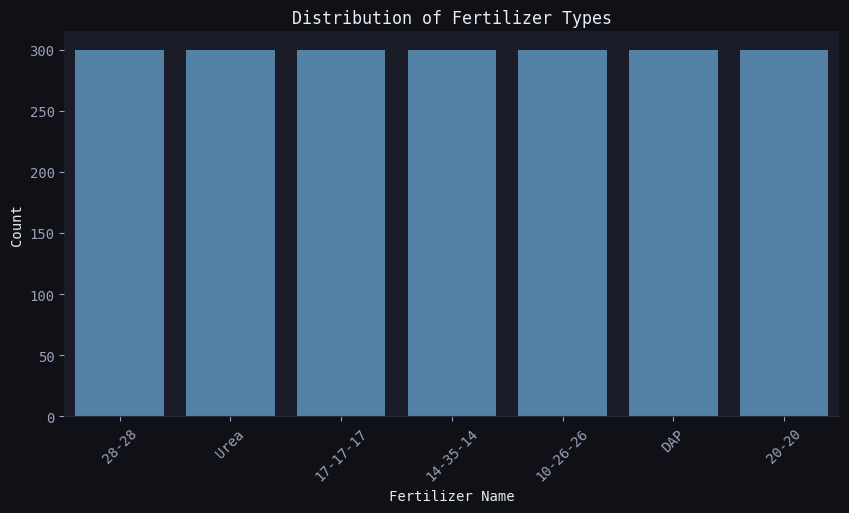

In [58]:
# Target variable distribution
plt.figure(figsize=(10,5))

order = df['Fertilizer Name'].value_counts().index

sns.countplot(
    x='Fertilizer Name',
    data=df,
    order=order,
    color='steelblue'
)

plt.xticks(rotation=45)
plt.title("Distribution of Fertilizer Types")
plt.xlabel("Fertilizer Name")
plt.ylabel("Count")
plt.show()

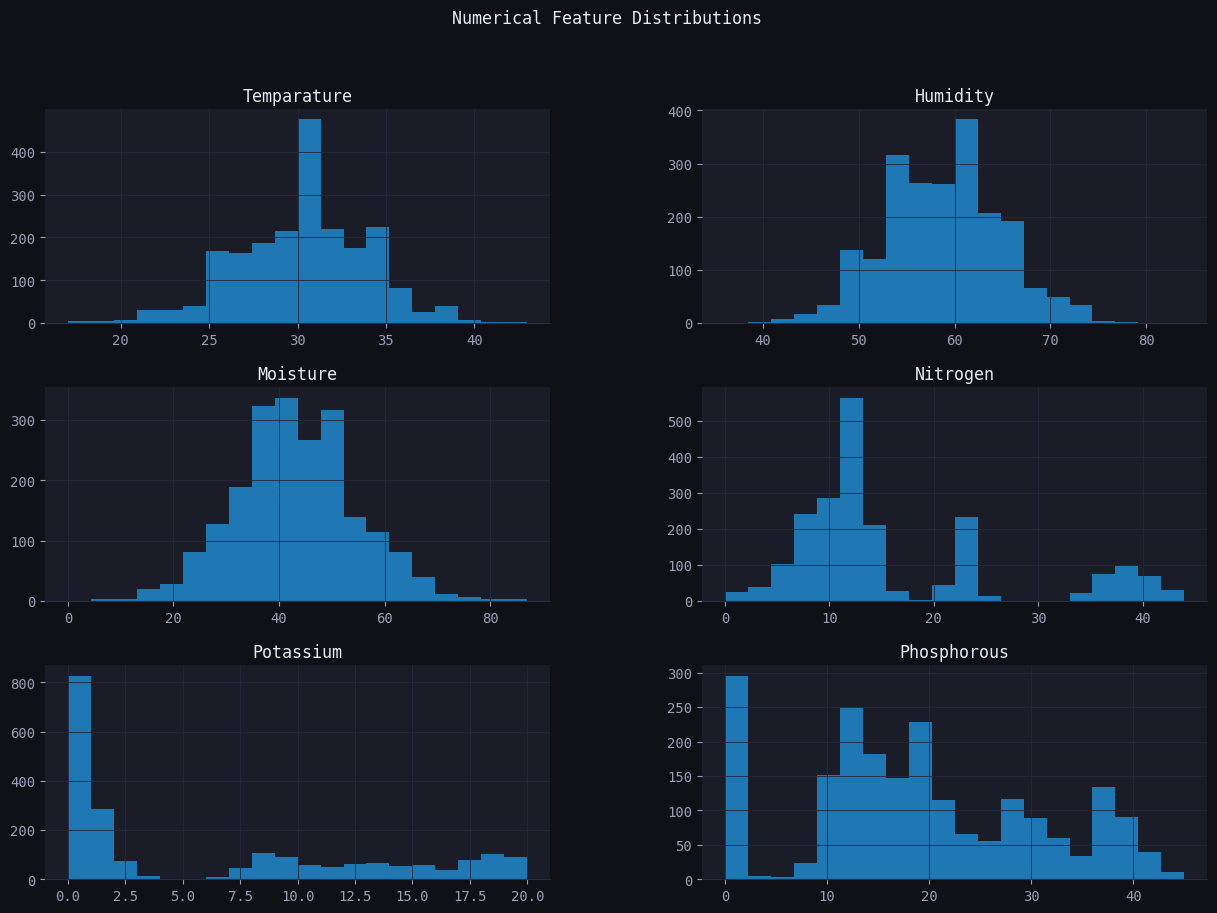

In [59]:
df[numerical_cols].hist(bins=20, figsize=(15,10))
plt.suptitle("Numerical Feature Distributions")
plt.show()

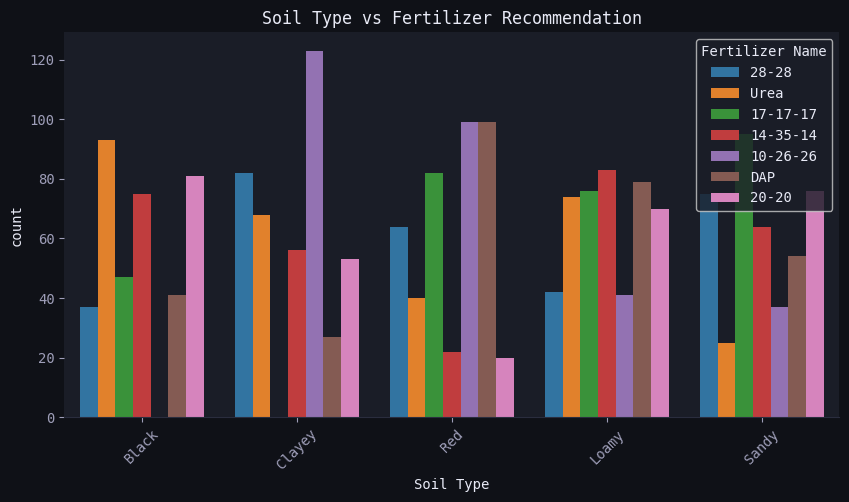

In [60]:
plt.figure(figsize=(10,5))
sns.countplot(x='Soil Type', hue='Fertilizer Name', data=df)
plt.xticks(rotation=45)
plt.title("Soil Type vs Fertilizer Recommendation")
plt.show()

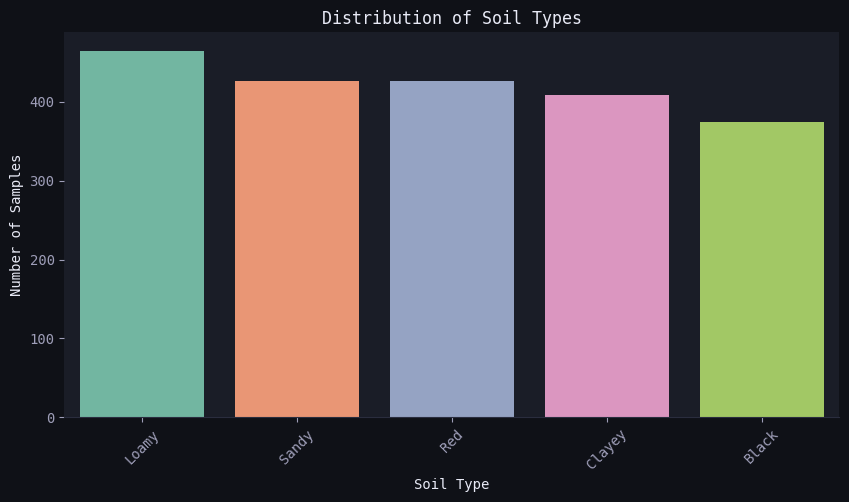

In [61]:
plt.figure(figsize=(10,5))

order = df['Soil Type'].value_counts().index

sns.countplot(
    x='Soil Type',
    data=df,
    order=order,
    palette='Set2'
)

plt.xticks(rotation=45)
plt.title("Distribution of Soil Types")
plt.xlabel("Soil Type")
plt.ylabel("Number of Samples")
plt.show()

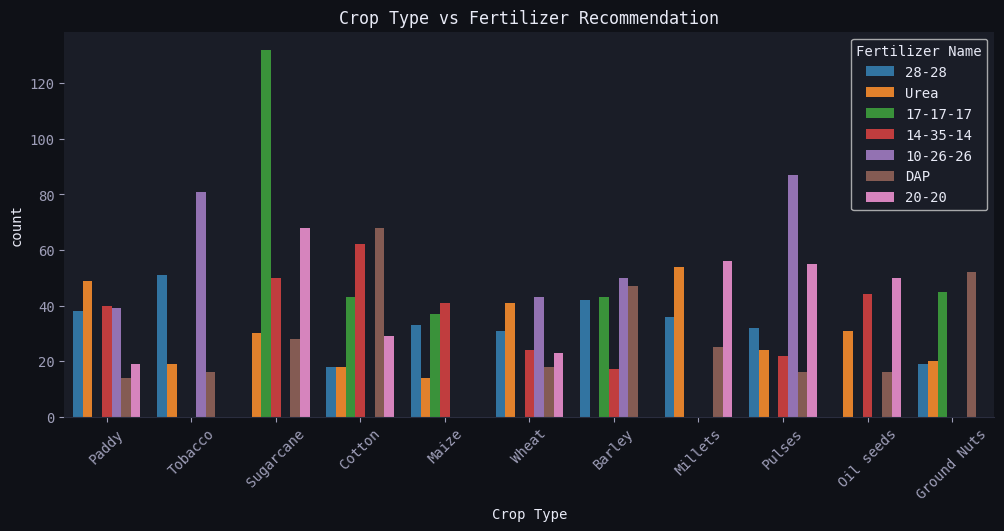

In [62]:
plt.figure(figsize=(12,5))
sns.countplot(x='Crop Type', hue='Fertilizer Name', data=df)
plt.xticks(rotation=45)
plt.title("Crop Type vs Fertilizer Recommendation")
plt.show()

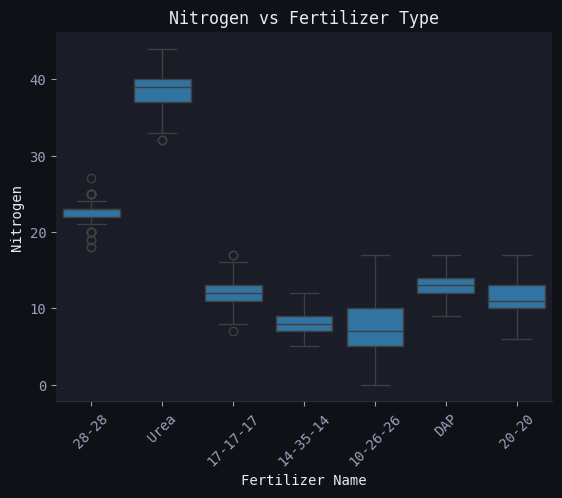

In [63]:
sns.boxplot(x='Fertilizer Name', y='Nitrogen', data=df)
plt.xticks(rotation=45)
plt.title("Nitrogen vs Fertilizer Type")
plt.show()

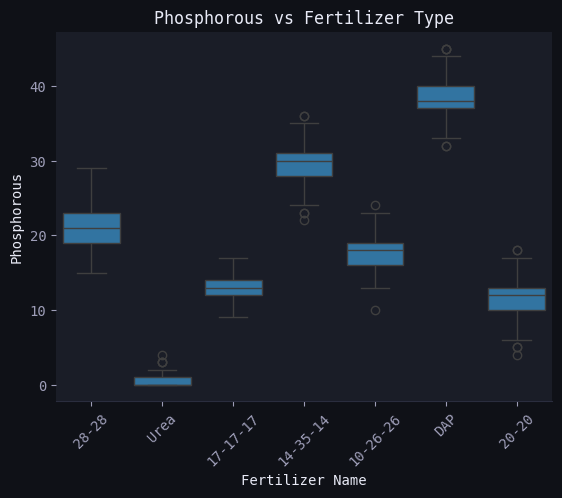

In [64]:
sns.boxplot(x='Fertilizer Name', y='Phosphorous', data=df)
plt.xticks(rotation=45)
plt.title("Phosphorous vs Fertilizer Type")
plt.show()

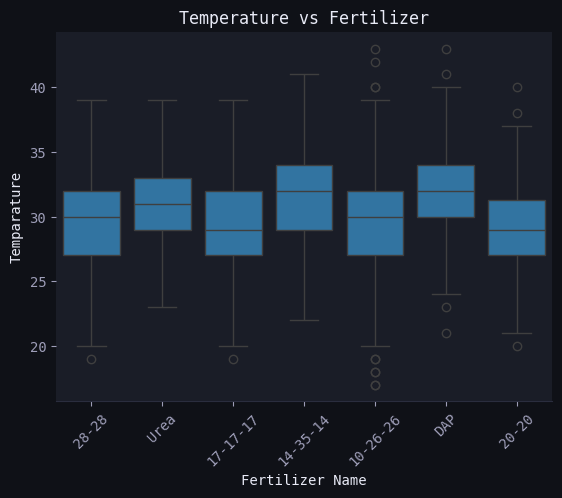

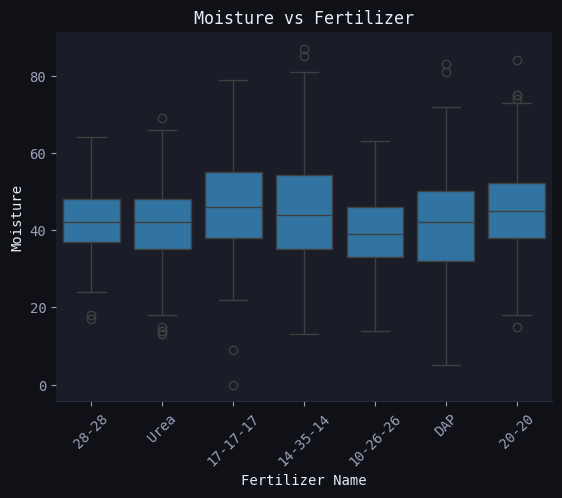

In [65]:
sns.boxplot(x='Fertilizer Name', y='Temparature', data=df)
plt.xticks(rotation=45)
plt.title("Temperature vs Fertilizer")
plt.show()

sns.boxplot(x='Fertilizer Name', y='Moisture', data=df)
plt.xticks(rotation=45)
plt.title("Moisture vs Fertilizer")
plt.show()

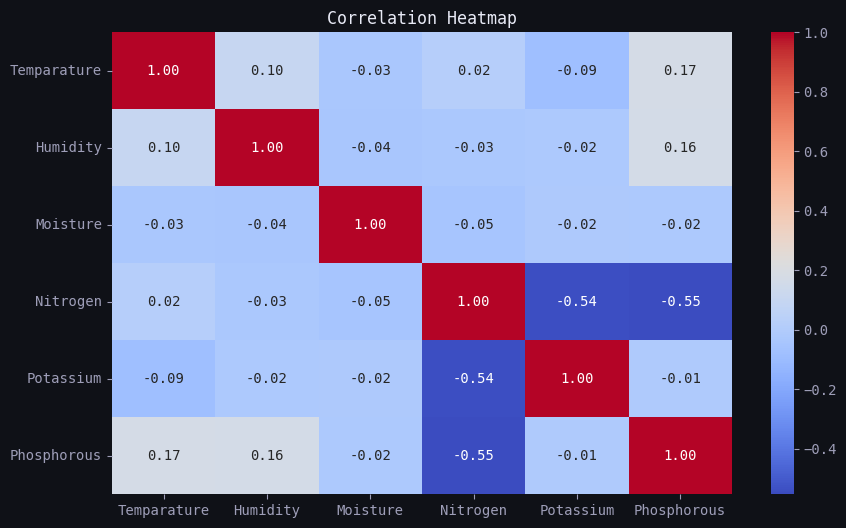

In [66]:
plt.figure(figsize=(10,6))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Feature Encoding 

In [67]:
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_target = LabelEncoder()

df['Soil Type']       = le_soil.fit_transform(df['Soil Type'])
df['Crop Type']       = le_crop.fit_transform(df['Crop Type'])
df['Fertilizer Name'] = le_target.fit_transform(df['Fertilizer Name'])

In [68]:
df.head()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Soil Type,Crop Type,Fertilizer Name
0,34,52,43,24,0,22,0,6,4
1,31,66,33,22,0,25,1,9,4
2,30,59,37,40,0,0,3,8,6
3,36,49,33,15,13,13,3,1,2
4,35,64,15,8,8,31,0,3,1


# Data splitting

In [69]:
X=df.drop('Fertilizer Name',axis=1)
y=df['Fertilizer Name']

In [70]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y ,random_state=42)

# Feature Scaling

In [71]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# Random Forest Classifier Model

In [72]:
rf=RandomForestClassifier(n_estimators=8)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=8)

In [73]:
y_pred_rfc=rf.predict(X_test)

In [74]:
print('accuracy score:',accuracy_score(y_test,y_pred_rfc))
print('confusion metrix:',confusion_matrix(y_test,y_pred_rfc))
print('classification report:\n',classification_report(y_test,y_pred_rfc))

accuracy score: 0.9904761904761905
confusion metrix: [[57  1  2  0  0  0  0]
 [ 0 60  0  0  0  0  0]
 [ 1  0 59  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  0  0  0  0 60  0]
 [ 0  0  0  0  0  0 60]]
classification report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97        60
           1       0.98      1.00      0.99        60
           2       0.97      0.98      0.98        60
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        60
           5       1.00      1.00      1.00        60
           6       1.00      1.00      1.00        60

    accuracy                           0.99       420
   macro avg       0.99      0.99      0.99       420
weighted avg       0.99      0.99      0.99       420



# SVM Model

In [75]:
svc=SVC(kernel='rbf')
svc.fit(X_train,y_train)

SVC()

In [76]:
y_pred_svc=svc.predict(X_test)

In [77]:
print('accuracy score:',accuracy_score(y_test,y_pred_svc))
print('confusion metrix:',confusion_matrix(y_test,y_pred_svc))
print('classification report:\n',classification_report(y_test,y_pred_svc))

accuracy score: 1.0
confusion metrix: [[60  0  0  0  0  0  0]
 [ 0 60  0  0  0  0  0]
 [ 0  0 60  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  0  0  0  0 60  0]
 [ 0  0  0  0  0  0 60]]
classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60
           2       1.00      1.00      1.00        60
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        60
           5       1.00      1.00      1.00        60
           6       1.00      1.00      1.00        60

    accuracy                           1.00       420
   macro avg       1.00      1.00      1.00       420
weighted avg       1.00      1.00      1.00       420



# Decision Tree Classifier Model 

In [78]:
dtc=DecisionTreeClassifier()
dtc.fit(X_train,y_train)

DecisionTreeClassifier()

In [79]:
y_pred_dtc=dtc.predict(X_test)

In [80]:
print('accuracy score:',accuracy_score(y_test,y_pred_dtc))
print('confusion metrix:',confusion_matrix(y_test,y_pred_dtc))
print('classification report:\n',classification_report(y_test,y_pred_dtc))

accuracy score: 0.9904761904761905
confusion metrix: [[56  0  4  0  0  0  0]
 [ 0 60  0  0  0  0  0]
 [ 0  0 60  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  0  0  0  0 60  0]
 [ 0  0  0  0  0  0 60]]
classification report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.97        60
           1       1.00      1.00      1.00        60
           2       0.94      1.00      0.97        60
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        60
           5       1.00      1.00      1.00        60
           6       1.00      1.00      1.00        60

    accuracy                           0.99       420
   macro avg       0.99      0.99      0.99       420
weighted avg       0.99      0.99      0.99       420



# KNN Model 

In [81]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [82]:
y_pred_knn=knn.predict(X_test)

In [83]:
print('accuracy score:',accuracy_score(y_test,y_pred_knn))
print('confusion metrix:',confusion_matrix(y_test,y_pred_knn))
print('classification report:\n',classification_report(y_test,y_pred_knn))

accuracy score: 0.9714285714285714
confusion metrix: [[53  0  7  0  0  0  0]
 [ 1 57  0  0  0  2  0]
 [ 1  0 59  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  1 59  0  0]
 [ 0  0  0  0  0 60  0]
 [ 0  0  0  0  0  0 60]]
classification report:
               precision    recall  f1-score   support

           0       0.96      0.88      0.92        60
           1       1.00      0.95      0.97        60
           2       0.89      0.98      0.94        60
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        60
           5       0.97      1.00      0.98        60
           6       1.00      1.00      1.00        60

    accuracy                           0.97       420
   macro avg       0.97      0.97      0.97       420
weighted avg       0.97      0.97      0.97       420



# XGBoost

In [84]:
xgb = XGBClassifier(random_state = 18)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [85]:
y_pred_xgb=xgb.predict(X_test)

In [86]:
print('accuracy score:',accuracy_score(y_test,y_pred_xgb))
print('confusion metrix:',confusion_matrix(y_test,y_pred_xgb))
print('classification report:',classification_report(y_test,y_pred_xgb))

accuracy score: 0.9976190476190476
confusion metrix: [[59  0  1  0  0  0  0]
 [ 0 60  0  0  0  0  0]
 [ 0  0 60  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  0 60  0  0]
 [ 0  0  0  0  0 60  0]
 [ 0  0  0  0  0  0 60]]
classification report:               precision    recall  f1-score   support

           0       1.00      0.98      0.99        60
           1       1.00      1.00      1.00        60
           2       0.98      1.00      0.99        60
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        60
           5       1.00      1.00      1.00        60
           6       1.00      1.00      1.00        60

    accuracy                           1.00       420
   macro avg       1.00      1.00      1.00       420
weighted avg       1.00      1.00      1.00       420



<Figure size 1200x600 with 0 Axes>

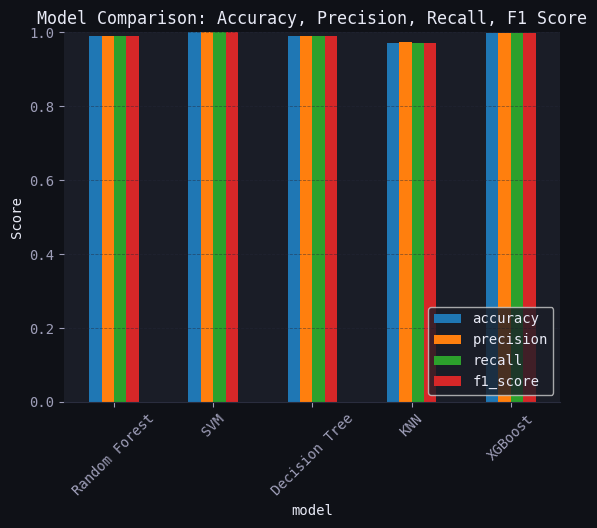

In [87]:
model_preds = {
    "Random Forest": y_pred_rfc,
    "SVM": y_pred_svc,
    "Decision Tree": y_pred_dtc,
    "KNN": y_pred_knn,
    "XGBoost": y_pred_xgb
}

comparison_metrics = []
for model_name, preds in model_preds.items():
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    comparison_metrics.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": report["macro avg"]["precision"],
        "recall": report["macro avg"]["recall"],
        "f1_score": report["macro avg"]["f1-score"]
    })

comparison_df = pd.DataFrame(comparison_metrics).set_index("model").round(4)
comparison_df
plt.figure(figsize=(12, 6))
comparison_df.plot(kind="bar")
plt.title("Model Comparison: Accuracy, Precision, Recall, F1 Score")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [88]:
import os
import pickle

os.makedirs("model", exist_ok=True)

with open("model/rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("model/column_names.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

# Save all three separately
with open("model/le_soil.pkl", "wb") as f:   pickle.dump(le_soil, f)
with open("model/le_crop.pkl", "wb") as f:   pickle.dump(le_crop, f)
with open("model/le_target.pkl", "wb") as f: pickle.dump(le_target, f)

with open("model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved rf_model.pkl, column_names.pkl, label_encoder.pkl, scaler.pkl in the model folder.")

Saved rf_model.pkl, column_names.pkl, label_encoder.pkl, scaler.pkl in the model folder.


Sample index   : 1704
Predicted label: DAP
Actual label   : DAP
Probabilities  : {'10-26-26': np.float64(0.0), '14-35-14': np.float64(0.0), '17-17-17': np.float64(0.0), '20-20': np.float64(0.0), '28-28': np.float64(0.0), 'DAP': np.float64(1.0), 'Urea': np.float64(0.0)}


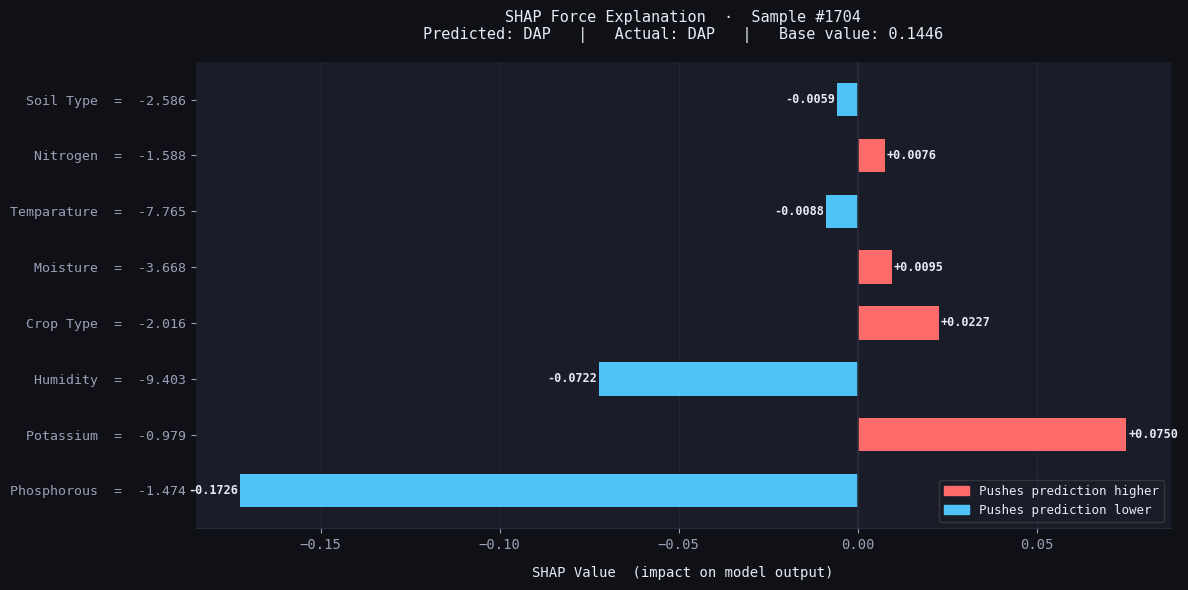

Saved → shap_force_plot.png


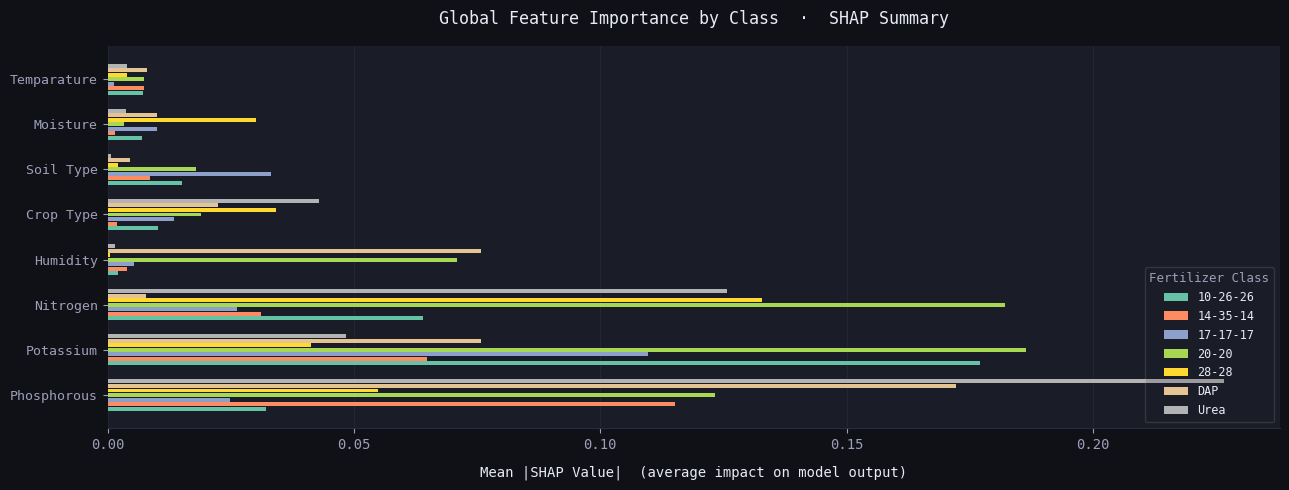

Saved → shap_summary_plot.png


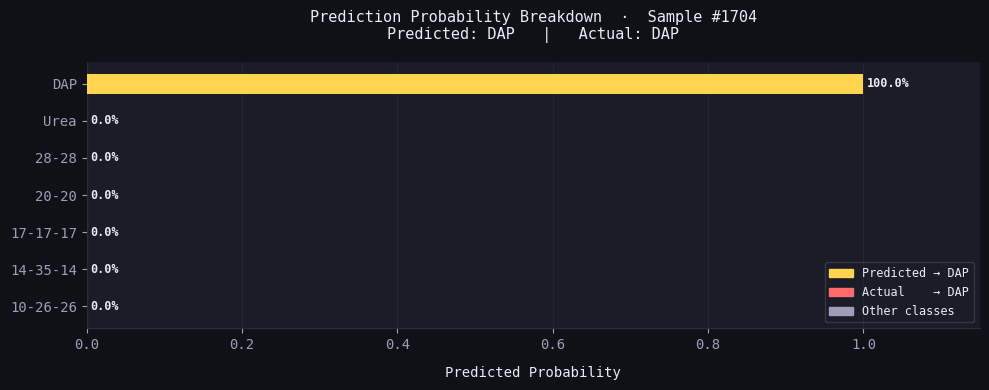

Saved → shap_probability_breakdown.png


In [92]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

# ─── GLOBAL STYLE CONFIGURATION ───────────────────────────────────────────────

PALETTE = {
    "bg":        "#0F1117",
    "panel":     "#1A1D27",
    "border":    "#2A2D3E",
    "text":      "#E8EAF6",
    "subtext":   "#9E9EB8",
    "positive":  "#FF6B6B",   # high SHAP → red
    "negative":  "#4FC3F7",   # low SHAP  → blue
    "accent":    "#FFD54F",   # highlight
    "gridline":  "#252839",
}

plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["panel"],
    "axes.edgecolor":    PALETTE["border"],
    "axes.labelcolor":   PALETTE["text"],
    "axes.titlecolor":   PALETTE["text"],
    "xtick.color":       PALETTE["subtext"],
    "ytick.color":       PALETTE["subtext"],
    "text.color":        PALETTE["text"],
    "grid.color":        PALETTE["gridline"],
    "grid.linewidth":    0.6,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "axes.spines.bottom":True,
})

SHAP_CMAP = LinearSegmentedColormap.from_list(
    "shap_custom",
    [PALETTE["negative"], "#FFFFFF20", PALETTE["positive"]],
    N=256
)

# ─── LOAD ARTIFACTS ───────────────────────────────────────────────────────────

with open(os.path.join("model", "rf_model.pkl"), "rb") as f:
    loaded_rf = pickle.load(f)
with open(os.path.join("model", "scaler.pkl"), "rb") as f:
    loaded_scaler = pickle.load(f)
with open(os.path.join("model", "D:\laptop\College\GP\Fertilizer_Recommendation\model\le_target.pkl"), "rb") as f:
    loaded_le = pickle.load(f)   # target encoder only — used for decoding predictions
with open(os.path.join("model", "column_names.pkl"), "rb") as f:
    loaded_columns = pickle.load(f)

predict_pipeline = Pipeline([
    ("scaler", loaded_scaler),
    ("rf_model", loaded_rf)
])

# ─── SAMPLE PREDICTION ────────────────────────────────────────────────────────

sample_index   = y_test.index[0]
sample_input   = X.loc[[sample_index]][loaded_columns]
sample_true    = y_test.loc[sample_index]

predicted_encoded = predict_pipeline.predict(sample_input)
predicted_probs   = predict_pipeline.predict_proba(sample_input)
predicted_label   = loaded_le.inverse_transform(predicted_encoded)
actual_label      = loaded_le.inverse_transform([sample_true])

print("Sample index   :", sample_index)
print("Predicted label:", predicted_label[0])
print("Actual label   :", actual_label[0])
print("Probabilities  :", dict(zip(loaded_le.classes_, predicted_probs[0].round(3))))

# ─── SHAP SETUP ───────────────────────────────────────────────────────────────

X_test_subset   = X_test[:100]
X_test_scaled   = loaded_scaler.transform(X_test_subset)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=loaded_columns)

explainer   = shap.TreeExplainer(loaded_rf)
shap_values = explainer.shap_values(X_test_scaled_df)

sample_position = 0
class_idx       = predicted_encoded[0]

if isinstance(shap_values, list):
    sample_shap_values = shap_values[class_idx][sample_position]
else:
    sample_shap_values = shap_values[sample_position, :, class_idx]

expected_val = (
    explainer.expected_value[class_idx]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_values_summary = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_values_summary = shap_values

# ─── PLOT 1 : FORCE PLOT (WATERFALL STYLE) ────────────────────────────────────

def plot_enhanced_force(expected_val, shap_vals, feature_vals, feature_names,
                        predicted_label, actual_label):
    """Custom waterfall / force plot with dark-mode styling."""

    pairs = sorted(
        zip(shap_vals, feature_vals, feature_names),
        key=lambda x: abs(x[0]),
        reverse=True
    )
    top_n = min(10, len(pairs))
    pairs = pairs[:top_n]
    sv, fv, fn = zip(*pairs)
    sv, fv, fn = list(sv), list(fv), list(fn)

    colors = [PALETTE["positive"] if v > 0 else PALETTE["negative"] for v in sv]

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(PALETTE["bg"])
    ax.set_facecolor(PALETTE["panel"])

    bars = ax.barh(
        range(top_n), sv,
        color=colors, height=0.6,
        linewidth=0, zorder=3
    )

    # Bar value labels
    for bar, val in zip(bars, sv):
        xpos = bar.get_width()
        offset = 0.003 * max(abs(v) for v in sv)
        ax.text(
            xpos + (offset if xpos >= 0 else -offset),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.4f}",
            va="center",
            ha="left" if xpos >= 0 else "right",
            fontsize=8.5,
            color=PALETTE["text"],
            fontweight="bold",
        )

    # Feature labels with value annotations
    ax.set_yticks(range(top_n))
    labels = [f"{name}  =  {val:.3f}" for name, val in zip(fn, fv)]
    ax.set_yticklabels(labels, fontsize=9.5)

    ax.axvline(0, color=PALETTE["border"], linewidth=1.2, zorder=4)
    ax.grid(axis="x", zorder=0)
    ax.set_xlabel("SHAP Value  (impact on model output)", labelpad=10, fontsize=10)
    ax.set_title(
        f"SHAP Force Explanation  ·  Sample #{sample_index}\n"
        f"Predicted: {predicted_label}   |   Actual: {actual_label}   |   "
        f"Base value: {expected_val:.4f}",
        fontsize=11, pad=16, color=PALETTE["text"]
    )

    pos_patch = mpatches.Patch(color=PALETTE["positive"], label="Pushes prediction higher")
    neg_patch = mpatches.Patch(color=PALETTE["negative"], label="Pushes prediction lower")
    ax.legend(
        handles=[pos_patch, neg_patch],
        loc="lower right", framealpha=0.15,
        fontsize=9, labelcolor=PALETTE["text"]
    )

    plt.tight_layout()
    plt.savefig("shap_force_plot.png", dpi=160, bbox_inches="tight",
                facecolor=PALETTE["bg"])
    plt.show()
    print("Saved → shap_force_plot.png")


plot_enhanced_force(
    expected_val, sample_shap_values,
    X_test_scaled_df.iloc[sample_position].values,
    loaded_columns,
    predicted_label[0], actual_label[0]
)

# ─── PLOT 2 : SUMMARY / IMPORTANCE BAR CHART ─────────────────────────────────

def plot_enhanced_summary(shap_values_list, feature_names, class_labels):
    """
    Multi-class SHAP importance bar chart.
    shap_values_list : list of 2-D arrays, one per class.
    """

    n_classes  = len(shap_values_list)
    mean_abs   = np.array([np.abs(sv).mean(axis=0) for sv in shap_values_list])
    # Sort by overall importance
    order      = np.argsort(mean_abs.sum(axis=0))[::-1]
    mean_abs   = mean_abs[:, order]
    feat_names = [feature_names[i] for i in order]
    top_n      = min(12, len(feat_names))
    mean_abs   = mean_abs[:, :top_n]
    feat_names = feat_names[:top_n]

    # Class colours – evenly spaced on a vivid palette
    class_colors = plt.cm.Set2(np.linspace(0, 1, n_classes))

    fig, ax = plt.subplots(figsize=(13, max(5, top_n * 0.55)))
    fig.patch.set_facecolor(PALETTE["bg"])
    ax.set_facecolor(PALETTE["panel"])

    bar_h   = 0.7 / n_classes
    y_base  = np.arange(top_n)

    for cls_i in range(n_classes):
        offsets = (cls_i - n_classes / 2) * bar_h + bar_h / 2
        bars = ax.barh(
            y_base + offsets,
            mean_abs[cls_i],
            height=bar_h * 0.88,
            color=class_colors[cls_i],
            label=class_labels[cls_i] if class_labels is not None else f"Class {cls_i}",
            zorder=3
        )

    ax.set_yticks(y_base)
    ax.set_yticklabels(feat_names, fontsize=9.5)
    ax.grid(axis="x", zorder=0)
    ax.set_xlabel("Mean |SHAP Value|  (average impact on model output)",
                  labelpad=10, fontsize=10)
    ax.set_title(
        "Global Feature Importance by Class  ·  SHAP Summary",
        fontsize=12, pad=16
    )
    ax.spines["bottom"].set_color(PALETTE["border"])

    legend = ax.legend(
        title="Fertilizer Class", title_fontsize=9,
        loc="lower right", framealpha=0.15,
        fontsize=8.5, labelcolor=PALETTE["text"]
    )
    legend.get_title().set_color(PALETTE["subtext"])

    plt.tight_layout()
    plt.savefig("shap_summary_plot.png", dpi=160, bbox_inches="tight",
                facecolor=PALETTE["bg"])
    plt.show()
    print("Saved → shap_summary_plot.png")


try:
    class_labels = list(loaded_le.classes_)
except Exception:
    class_labels = None

plot_enhanced_summary(shap_values_summary, loaded_columns, class_labels)

# ─── PLOT 3 : PREDICTION PROBABILITY RADAR / BREAKDOWN ───────────────────────

def plot_probability_breakdown(probs, class_labels, predicted_label, actual_label):
    """Clean horizontal bar chart of class probabilities."""

    order  = np.argsort(probs)
    probs  = probs[order]
    labels = [class_labels[i] for i in order]
    colors = [
        PALETTE["accent"] if lbl == predicted_label else
        (PALETTE["positive"] if lbl == actual_label else PALETTE["subtext"])
        for lbl in labels
    ]

    fig, ax = plt.subplots(figsize=(10, max(4, len(labels) * 0.45)))
    fig.patch.set_facecolor(PALETTE["bg"])
    ax.set_facecolor(PALETTE["panel"])

    bars = ax.barh(labels, probs, color=colors, height=0.55, zorder=3)

    for bar, p in zip(bars, probs):
        ax.text(
            bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{p:.1%}", va="center", ha="left",
            fontsize=8.5, color=PALETTE["text"], fontweight="bold"
        )

    ax.set_xlim(0, min(1.15, max(probs) * 1.35))
    ax.set_xlabel("Predicted Probability", labelpad=10, fontsize=10)
    ax.set_title(
        f"Prediction Probability Breakdown  ·  Sample #{sample_index}\n"
        f"Predicted: {predicted_label}   |   Actual: {actual_label}",
        fontsize=11, pad=16
    )
    ax.grid(axis="x", zorder=0)
    ax.axvline(0, color=PALETTE["border"], linewidth=1)

    legend_patches = [
        mpatches.Patch(color=PALETTE["accent"],   label=f"Predicted → {predicted_label}"),
        mpatches.Patch(color=PALETTE["positive"], label=f"Actual    → {actual_label}"),
        mpatches.Patch(color=PALETTE["subtext"],  label="Other classes"),
    ]
    ax.legend(handles=legend_patches, loc="lower right",
              framealpha=0.15, fontsize=8.5, labelcolor=PALETTE["text"])

    plt.tight_layout()
    plt.savefig("shap_probability_breakdown.png", dpi=160,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.show()
    print("Saved → shap_probability_breakdown.png")


plot_probability_breakdown(
    predicted_probs[0],
    list(loaded_le.classes_),
    predicted_label[0], actual_label[0]
)

In [95]:
df.head()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Soil Type,Crop Type,Fertilizer Name
0,34,52,43,24,0,22,0,6,4
1,31,66,33,22,0,25,1,9,4
2,30,59,37,40,0,0,3,8,6
3,36,49,33,15,13,13,3,1,2
4,35,64,15,8,8,31,0,3,1
